In [1]:
# Define problem
# Always two features
# Ideal weight of first feature is always 0.5, ideal weight of second feature is configurable
# Whether features are independent is configurable, when colinear, they are the same target feature with different amounts of noise
# Noise for the first feature is always 0.1, noise for the second feature is configurable
# Note that all of the three lines are like a small version of the feature sifting setup I'm already using with how features are generated with noise coefficients and such


# First experiment:
# Independent features, ideal weight of second feature with ideal weights of 0.1, 0.3, 0.5, 0.7, and 0.9
# The second feature should also have noise of 0.1
# Both features are trained with LMS with a step-size of 0.01 for 100k steps
# I want to plot several plots, vertically stacked, each for a different ideal weight of the second feature
# Each plot should include lines for:
#   - The current weights of both features
#   - A dashed line for the ideal weight of the second feature
#   - Traces of changes to the weights with varying decay rates (0.9, 0.99, 0.999)
#   - h value from IDBD (compute even though learning happens with a constant step-size)
#   - h value from IDBD3 (compute even though learning happens with a constant step-size)


# The goal of this experiment is to figure out which, if any, of the metrics I've mentioned would be sufficient to determine when a feature should be protected
# The indicators I'm considering are traces of changes to the weights, traces to changes to the step-size (when using idbd),
#   and the h value of IDBD or IDBD3 (when its sign flips) (which can be computed even when not using IDBD).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def make_problem_data(
    n_steps,
    target_weights,          # teacher weight on each feature's CLEAN signal (scalar or list)
    *,
    feature_noise=0.0,       # noise coefficient c per feature (scalar or list)
    target_noise_std=0.1,    # std of additive Gaussian noise on the target
    shared_signal=False,     # if True, all features are noisy views of ONE signal
    seed=0,
):
    """Generate (features, target) for the feature-sifting linear-regression probe.

    The target is a fixed "teacher network": ``y = sum_j target_weights[j] * s_j
    + noise``, built from the CLEAN signals ``s_j``. The learner instead sees the
    noisy features ``f_j = (1 - c_j) * s_j + c_j * U(-1, 1)``. The teacher weights
    are held fixed regardless of the feature noise; the learner's *optimal* weight
    on a noisy feature is attenuated away from the teacher weight (regression
    dilution -- see ``optimal_weight``), so the dashed reference in the plots is
    the computed optimum, not the teacher weight.

    Every knob that may vary across experiments is a parameter:

    - ``target_weights``: teacher weight per feature on its clean signal -> sets
      the number of features. With clean features (``c = 0``) this is also the
      learner's optimal weight.
    - ``feature_noise``: per-feature noise coefficient ``c`` in
      ``f = (1 - c) * s + c * U(-1, 1)``;  ``c = 0`` gives a clean feature.
    - ``target_noise_std``: std of the Gaussian noise added to the target.
    - ``shared_signal``: if True every feature is a noisy view of the *same*
      underlying signal (the colinear / "blocking" case); otherwise each feature
      has its own independent signal.

    Returns ``features`` (n_steps, n_feat) and ``y`` (n_steps,).
    """
    rng = np.random.default_rng(seed)
    target_weights = np.atleast_1d(np.asarray(target_weights, dtype=float))
    n_feat = len(target_weights)
    c = np.broadcast_to(np.asarray(feature_noise, dtype=float), (n_feat,))

    # underlying clean signals
    if shared_signal:
        s = rng.uniform(-1.0, 1.0, size=n_steps)
        signals = [s] * n_feat
    else:
        signals = [rng.uniform(-1.0, 1.0, size=n_steps) for _ in range(n_feat)]

    features = np.empty((n_steps, n_feat))
    y = rng.normal(0.0, target_noise_std, size=n_steps)
    for j in range(n_feat):
        feat_noise = rng.uniform(-1.0, 1.0, size=n_steps)
        features[:, j] = (1 - c[j]) * signals[j] + c[j] * feat_noise
        y = y + target_weights[j] * signals[j]   # teacher weight on the clean signal

    return features, y


def optimal_weight(target_weight, feature_noise):
    """Least-squares optimal weight on a single *independent* noisy feature.

    With ``f = (1 - c) * s + c * u`` (Var(s) == Var(u)) and target component
    ``target_weight * s``, the optimum is
        ``w* = Cov(f, y) / Var(f) = target_weight * (1 - c) / ((1 - c)**2 + c**2)``.
    The learner shrinks the weight (regression attenuation) as the feature gets
    noisier:  ``w* -> target_weight`` at ``c = 0`` and ``w* -> 0`` as ``c -> 1``.
    Assumes the feature's signal is independent of the other features' signals.
    """
    c = np.asarray(feature_noise, dtype=float)
    return target_weight * (1 - c) / ((1 - c) ** 2 + c ** 2)


In [4]:
# ---------------------------------------------------------------------------
# First experiment: a single feature with clean inputs (no feature noise) and a
# noisy target, learned from a zero weight with constant-step-size LMS, while we
# *observe* candidate "maturity" indicators for its weight.
#
# Learning is plain LMS; the IDBD / IDBD3 h-traces are computed alongside with
# the same constant step-size, exactly as the project optimisers do:
#   IDBD : h <- h * max(1 - step_size*f**2, 0) + step_size * loss_grad
#   IDBD3: h <- h * max(1 - step_size*f**2, 0) +             loss_grad
# with loss_grad = 2*error*f. They never feed back into the weights.
# (With a constant step-size the two share the same decay term and differ only by
#  the factor step_size, so h_idbd == step_size * h_idbd3 exactly -- they coincide
#  once normalized.)
# ---------------------------------------------------------------------------

STEP_SIZE = 0.01
N_STEPS = 10_000
IDEAL_WEIGHTS = [0.0, 0.001, 0.01, 0.1, 0.5, 1.0]
TRACE_DECAYS = [0.9, 0.99, 0.999]


def run_lms_with_indicators(features, y, step_size=STEP_SIZE, trace_decays=TRACE_DECAYS,
                            w_init=None):
    """LMS over `features` (n_steps, n_feat); indicators are tracked for the
    feature under study, taken to be the LAST column. `step_size` is the constant
    LMS / IDBD step-size and the number of steps is set by len(features), so both
    are configurable per run. `w_init` defaults to zeros (a fresh weight); pass a
    vector to start e.g. an established weight at its optimum in the later blocking
    experiments."""
    n_steps, n_feat = features.shape
    tracked = n_feat - 1
    decays = np.asarray(trace_decays, dtype=float)
    n_dec = len(decays)

    w = np.zeros(n_feat) if w_init is None else np.asarray(w_init, dtype=float)
    h_idbd = 0.0
    h_idbd3 = 0.0
    dw_tr = np.zeros(n_dec)

    w_hist = np.empty((n_steps, n_feat))
    dw_trace_hist = np.empty((n_steps, n_dec))
    h_idbd_hist = np.empty(n_steps)
    h_idbd3_hist = np.empty(n_steps)

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]              # y_hat - y  (project convention)

        fi = f[tracked]
        loss_grad = 2.0 * error * fi             # d(error**2)/dw_tracked
        decay_term = fi * fi                     # prediction-grad squared

        # IDBD / IDBD3 h-traces (observed only, constant step-size)
        keep = max(0.0, 1.0 - step_size * decay_term)
        h_idbd = h_idbd * keep + step_size * loss_grad
        h_idbd3 = h_idbd3 * keep + loss_grad

        # LMS weight update (constant step-size) for every weight
        dw = -step_size * (2.0 * error * f)
        w = w + dw

        # EMA traces of the tracked weight's changes
        dw_tr = decays * dw_tr + (1.0 - decays) * dw[tracked]

        w_hist[t] = w
        dw_trace_hist[t] = dw_tr
        h_idbd_hist[t] = h_idbd
        h_idbd3_hist[t] = h_idbd3

    return {'w': w_hist, 'dw_trace': dw_trace_hist,
            'h_idbd': h_idbd_hist, 'h_idbd3': h_idbd3_hist}


results = {}
for w_ideal in IDEAL_WEIGHTS:
    # single clean feature (no feature noise), target noise = 0.1
    feats, targ = make_problem_data(N_STEPS, [w_ideal], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    results[w_ideal] = run_lms_with_indicators(feats, targ, step_size=STEP_SIZE)


In [5]:
def _norm_peak(a):
    m = np.max(np.abs(a))
    return a / m if m > 0 else a

W_COLOR = 'black'
DW_COLORS = ['#3953e2', '#9923DC', '#029999']  # Brighter indigo, purple, dark aqua
H_IDBD3_COLOR = '#FF3300'  # slightly redder blood orange (stand-out)

### Reading the plots

One panel per ideal weight $w^*$ (including $w^* = 0$ — a useless feature whose weight
should stay at zero). A single feature with clean inputs is learned from a zero weight;
all the noise lives in the target ($\sigma = 0.1$).

**Left axis (true scale, black):** the weight (solid) and its ideal value (dashed). The
grey vertical line marks where the weight first reaches 90% of its ideal — a rough
"matured" reference (omitted for $w^* = 0$).

**Right axis (linear, coloured):** the candidate maturity indicators, each normalized to
unit peak so they are comparable (raw magnitudes differ by orders of magnitude). All are
shown in the weight-change sign convention ($-h$), so each indicator is positive while
the weight grows and collapses toward (and flips around) zero once the weight matures.

The IDBD / IDBD3 $h$-traces use the project's exact recursion
$h_t = h_{t-1}\,\max(1 - \alpha f^2,\,0) + (\alpha\ \text{or}\ 1)\cdot\text{loss\_grad}$,
with $\alpha$ held constant. They share the *same* decay multiplier and their additive
terms differ only by the constant factor $\alpha$, so $h^{\text{IDBD}}_t = \alpha\,
h^{\text{IDBD3}}_t$ for all $t$ — i.e. they are exactly proportional and coincide after
normalization. They only diverge once $\alpha$ is allowed to adapt (then the decay
multipliers differ too), which is a later experiment.


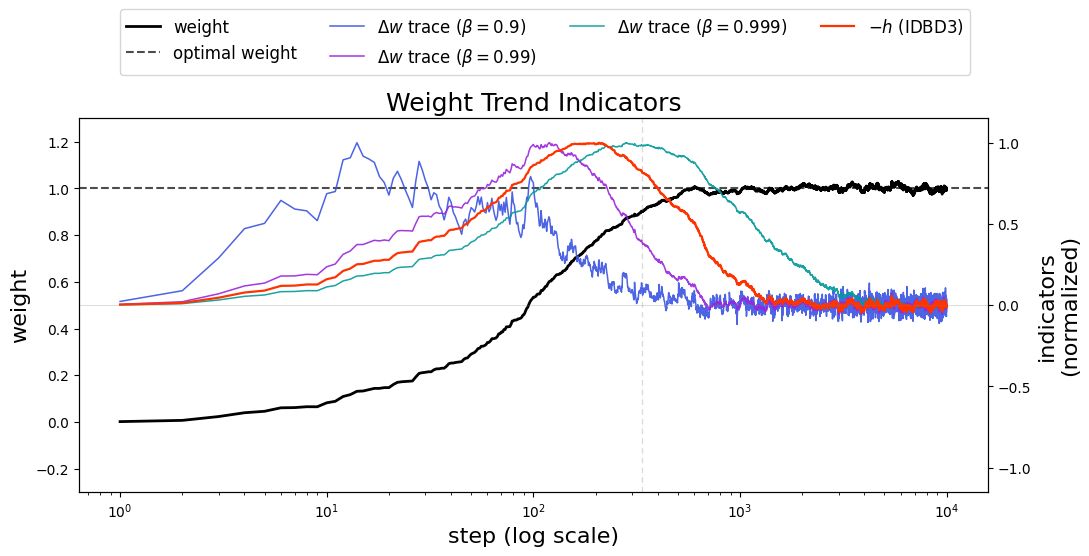

In [6]:

# Only plot the first optimal weight (single plot)
plot_steps = np.arange(1, N_STEPS + 1)

w_ideal = IDEAL_WEIGHTS[-1]
res = results[w_ideal]
w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

fig, ax = plt.subplots(figsize=(11, 5))
# --- left axis: the weight (true scale, black) ---
ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, label='optimal weight')
ax.set_xscale('log')
ax.set_ylabel('weight', fontsize=16)
ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
ax.set_title(f'Weight Trend Indicators', fontsize=18)

# rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
if w_opt > 0:
    hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
    if len(hit):
        ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3)

# --- right axis: normalized maturity indicators (one colour each) ---
ax2 = ax.twinx()
for k, d in enumerate(TRACE_DECAYS):
    ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
             color=DW_COLORS[k], lw=1.1, alpha=0.9, label=f'$\Delta w$ trace ($\\beta = {d}$)')
ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
         label='$-h$ (IDBD3)')
ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
ax2.set_ylim(-1.15, 1.15)
ax2.set_ylabel('indicators\n(normalized)', fontsize=16)

ax.set_xlabel('step (log scale)', fontsize=16)

# Build legend with left and right handles/labels
hL, lL = ax.get_legend_handles_labels()
hR, lR = ax2.get_legend_handles_labels()
# Place the legend just above the axes, closer to the plot to reduce empty space
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.12),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))  # adjust so legend fits closely above plot
plt.show()


/tmp/ipykernel_55054/828059091.py:15: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)


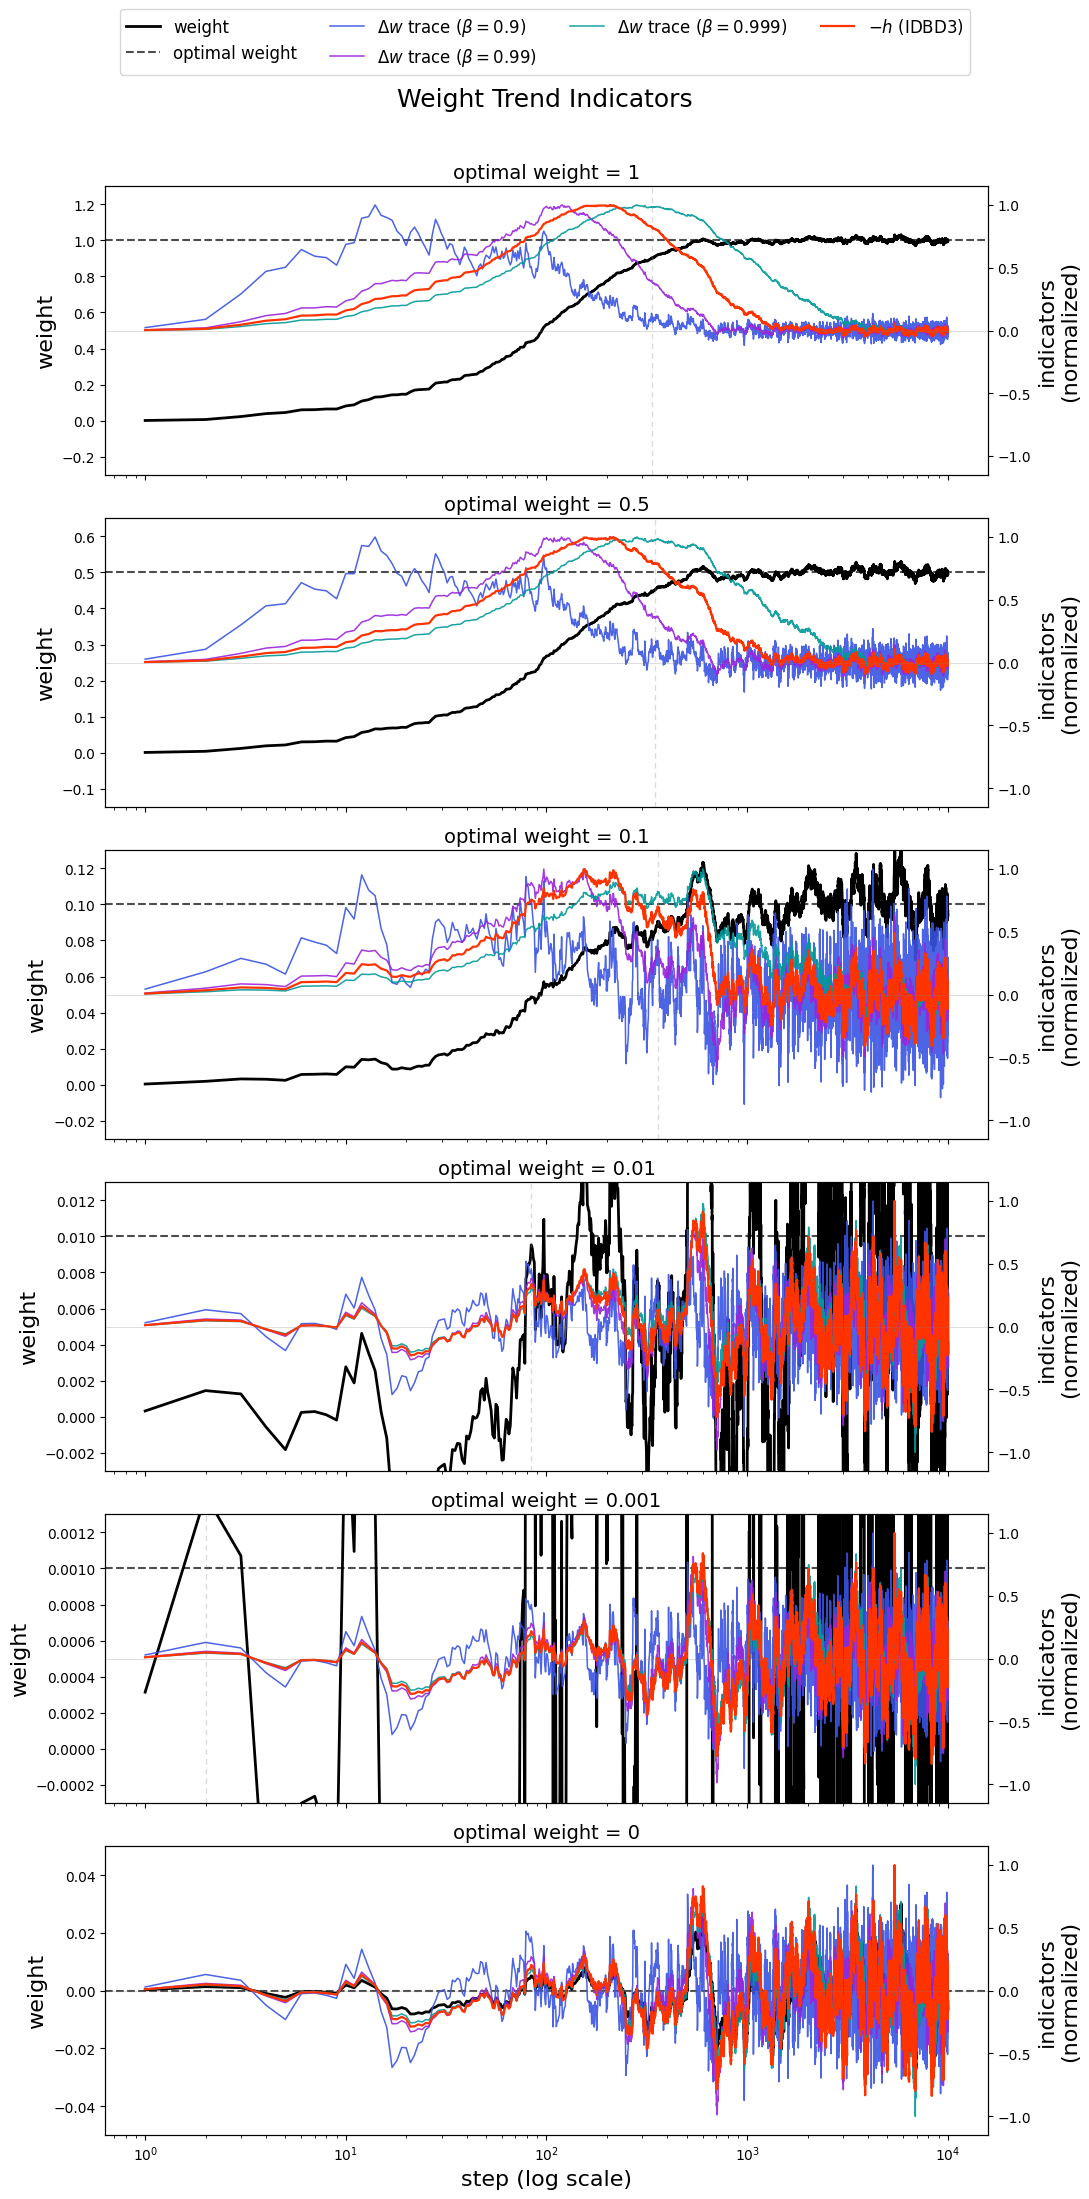

In [7]:
plot_steps = np.arange(1, N_STEPS + 1)
fig, axes = plt.subplots(len(IDEAL_WEIGHTS), 1,
                         figsize=(11, 3.6 * len(IDEAL_WEIGHTS)), sharex=True)
ax2_first = None
for ax, w_ideal in zip(axes, IDEAL_WEIGHTS[::-1]):
    res = results[w_ideal]
    w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

    # --- left axis: the weight (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight')
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'optimal weight = {w_opt:.3g}', fontsize=14)

    # rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3)

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.02),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Second experiment: sweep the step-size (optimal weight fixed at $w^* = 0.001$)

Exactly the first experiment's single clean-feature / noisy-target setup, but the
optimal weight is now held fixed at $w^* = 0.001$ and the constant LMS / IDBD
step-size is swept instead. One panel per step-size; the indicators, axes,
normalization, and (fixed) weight y-range are unchanged from the first experiment.


In [13]:
# ---------------------------------------------------------------------------
# Second experiment: identical single clean-feature / noisy-target setup as the
# first experiment, but now the optimal weight is held FIXED at 0.001 and the
# constant LMS / IDBD step-size is what we sweep (instead of sweeping the ideal
# weight). Clean feature -> optimal weight == teacher weight, so target_weights
# = [0.001] gives an optimal weight of 0.001 exactly. Everything else (the run
# function, indicators, noise, n_steps) is unchanged from the first experiment.
# ---------------------------------------------------------------------------

OPT_WEIGHT_SS = 0.01
STEP_SIZES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
n_steps = 1_000_000

results_ss = {}
for ss in STEP_SIZES:
    # single clean feature (no feature noise), target noise = 0.1
    feats, targ = make_problem_data(n_steps, [OPT_WEIGHT_SS], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    results_ss[ss] = run_lms_with_indicators(feats, targ, step_size=ss)


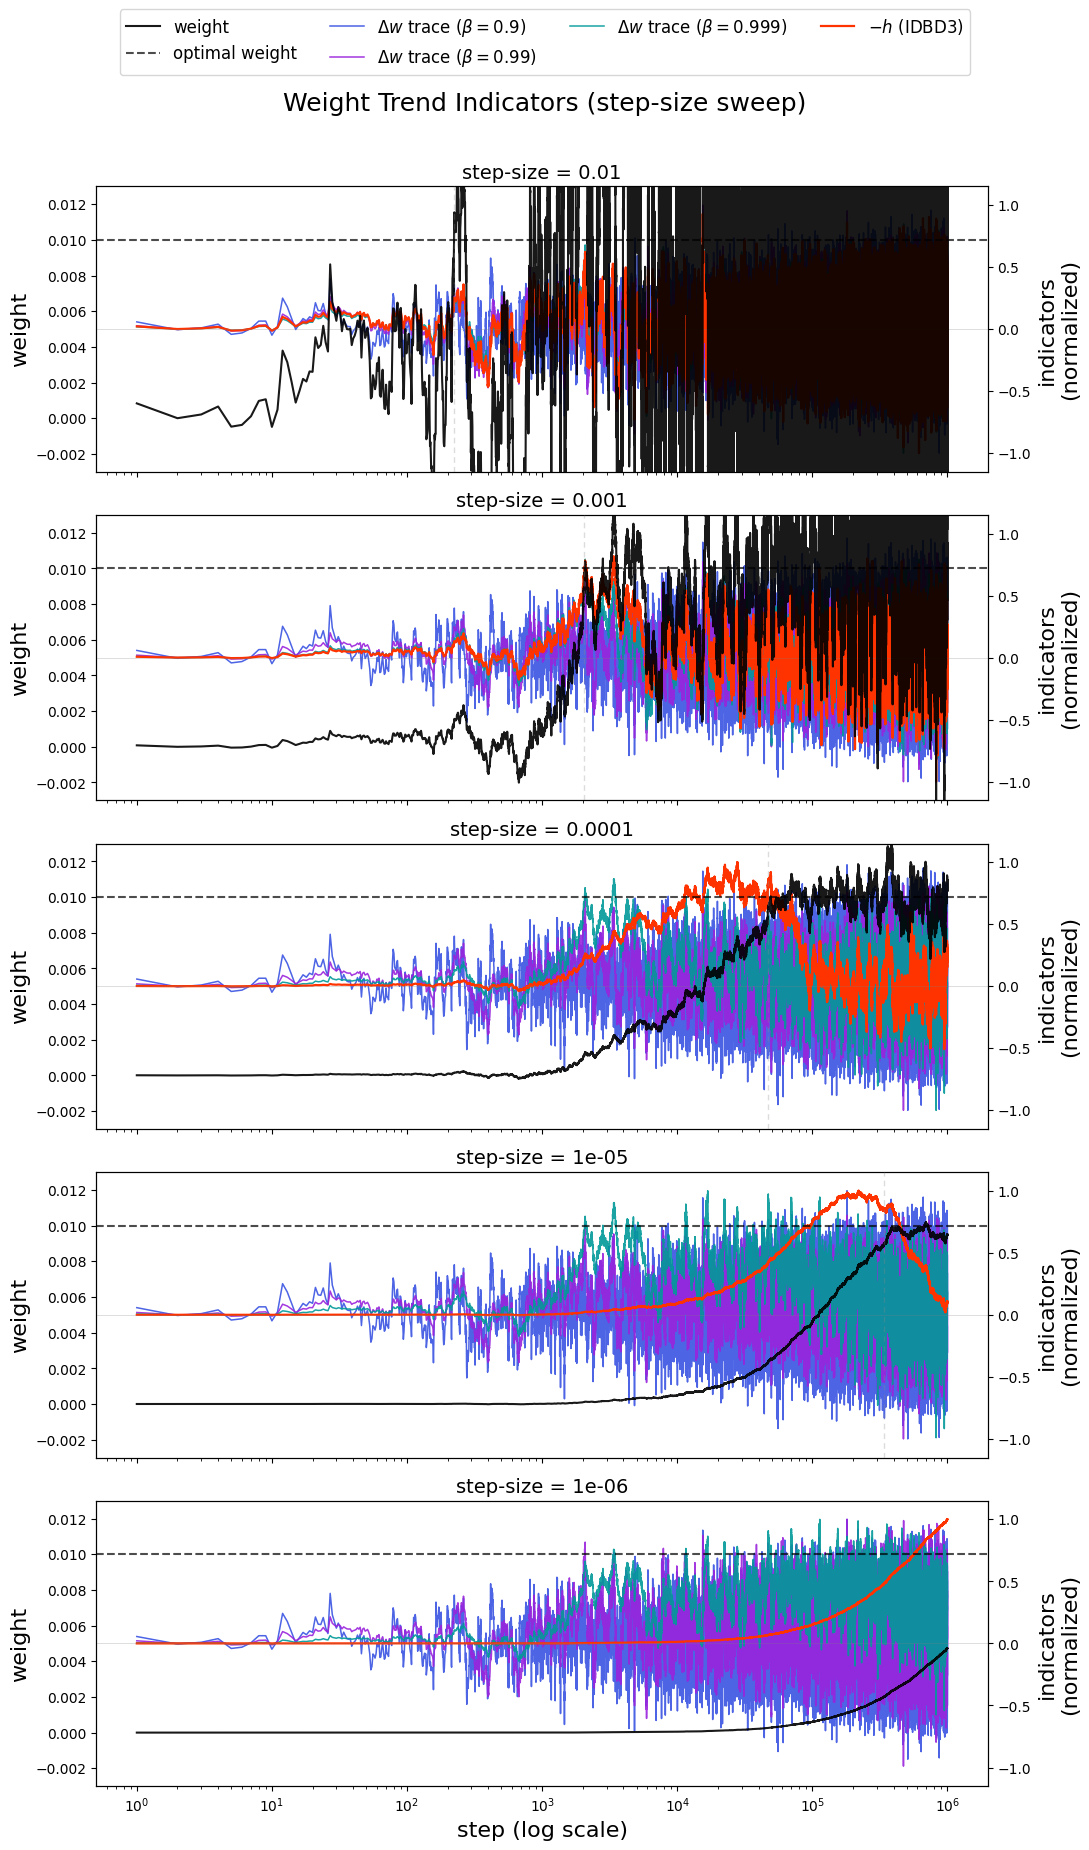

In [21]:
plot_steps = np.arange(1, n_steps + 1)
w_opt = optimal_weight(OPT_WEIGHT_SS, 0.0)   # clean feature -> equals 0.001
fig, axes = plt.subplots(len(STEP_SIZES), 1,
                         figsize=(11, 3.6 * len(STEP_SIZES)), sharex=True)
ax2_first = None
for ax, ss in zip(axes, STEP_SIZES[::-1]):
    res = results_ss[ss]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weight (true scale, black), now plotted after the right axis lines ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=1.5, label='weight', zorder=10, alpha=0.9)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'step-size = {ss:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through


    # rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (step-size sweep)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()
